In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import SAGEConv, GATConv
from sklearn.neighbors import BallTree
from sklearn.preprocessing import StandardScaler
from pathlib import Path
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
import wandb
import optuna
import seaborn as sns
from scipy import stats
import itertools

In [2]:
root = Path("..").resolve()

score_cols = [
    "coating_deterioration_score",
    "masonry_degradation_score",
    "moisture_bio_damage_score",
    "vandalism_score",
]

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Базовый пайплайн работы с GNN моделями

### 1. Загрузка данных

In [4]:
# основной датасет: все здания с признаками и разметкой
df = pd.read_csv(root / 'data/interim/gnn_node_features-b2-08.05.csv')

### 2. Подготовка признаков и заполнение пропусков

In [3]:
# признаки для графа схожести, включая архитектурный стиль
similarity_cols = [
    'area_m2', 'perimeter_m',
    'year_built', 'floors', 'last_modified_year',
    'distance_to_water_m', 'distance_to_major_road_m',
    'distance_to_metro_m', 'distance_to_tram_rail_m',
    'amenity_count_300m', 'distance_to_park_m', 'distance_to_pedestrian_m',
    'dist_Василеостровский район', 'dist_Петроградский район', 'dist_Центральный район',
    *[c for c in df.columns if c.startswith('style_')],
]
feature_cols = similarity_cols

### 3. Построение графа схожести

Рёбра соединяют здания, **похожие архитектурно** (год постройки, размер, этажность), а не географически близкие.

`k=8` соседей, евклидово расстояние в нормализованном пространстве признаков.

In [4]:
k_sim = 8

# k ближайших соседей по признакам
X_sim = StandardScaler().fit_transform(df[similarity_cols].values)
sim_tree = BallTree(X_sim, metric="euclidean")
sim_dist, sim_idx = sim_tree.query(X_sim, k=k_sim + 1)

# веса рёбер
sigma = np.median(sim_dist[:, 1:])
src_list = np.repeat(np.arange(len(df)), k_sim)
dst_list = sim_idx[:, 1:].flatten()
w_list = np.exp(-sim_dist[:, 1:].flatten() / sigma)

edge_index = torch.tensor([src_list, dst_list], dtype=torch.long)
edge_attr = torch.tensor(w_list, dtype=torch.float)

/tmp/ipykernel_4721/3741208010.py:14: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  edge_index = torch.tensor([src_list, dst_list], dtype=torch.long)


### 4. PyTorch Geometric Data объект

In [ ]:
# нормализуем признаки и собираем PyG Data объект
scaler = StandardScaler()
X_norm = scaler.fit_transform(df[feature_cols].values)
x = torch.tensor(X_norm, dtype=torch.float)

y_np = df[score_cols].values.astype(float)
y = torch.tensor(y_np, dtype=torch.float)

# train/test 
labeled_idx = np.where(df["is_labeled"].values == 1)[0]
n_val = max(1, int(len(labeled_idx) * 0.15))
val_idx = labeled_idx[:n_val]
train_idx = labeled_idx[n_val:]

train_mask = torch.zeros(len(df), dtype=torch.bool)
val_mask = torch.zeros(len(df), dtype=torch.bool)
train_mask[train_idx] = True
val_mask[val_idx] = True

data = Data(x=x, edge_index=edge_index, edge_attr=edge_attr,
            y=y, train_mask=train_mask, val_mask=val_mask)

### 5. Архитектура GraphSAGE

In [8]:
class DamageGNN(nn.Module):
    def __init__(self, in_ch, hidden=64, out_ch=4, dropout=0.4):
        super().__init__()
        self.dropout = dropout
        self.conv1 = SAGEConv(in_ch, hidden)
        self.conv2 = SAGEConv(hidden, hidden)
        self.conv3 = SAGEConv(hidden, hidden // 2)
        self.head = nn.Linear(hidden // 2, out_ch)

    def forward(self, x, edge_index):
        x = F.relu(self.conv1(x, edge_index))
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = F.relu(self.conv2(x, edge_index))
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = F.relu(self.conv3(x, edge_index))
        return torch.sigmoid(self.head(x))  # скоры [0, 1]


model = DamageGNN(in_ch=x.shape[1]).to(device)
data = data.to(device)

### 6. Обучение

In [9]:
optimizer = torch.optim.Adam(model.parameters(), lr=3e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, patience=30, factor=0.5, min_lr=1e-5
)

max_epochs = 1000
patience = 60
best_val_mae = float("inf")
best_state = None
no_improve = 0

train_means = data.y[data.train_mask].mean(dim=0)
naive_val_mae = (data.y[data.val_mask] - train_means).abs().mean().item()

history = {"train_loss": [], "val_mae": []}

for epoch in range(1, max_epochs + 1):
    model.train()
    optimizer.zero_grad()
    pred = model(data.x, data.edge_index)
    loss = F.mse_loss(pred[data.train_mask], data.y[data.train_mask])
    loss.backward()
    optimizer.step()

    model.eval()
    with torch.no_grad():
        pred_eval = model(data.x, data.edge_index)
        val_mae = (pred_eval[data.val_mask] - data.y[data.val_mask]).abs().mean().item()

    scheduler.step(val_mae)
    history["train_loss"].append(loss.item())
    history["val_mae"].append(val_mae)

    if val_mae < best_val_mae:
        best_val_mae = val_mae
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        no_improve = 0
    else:
        no_improve += 1
        if no_improve >= patience:
            print(f"Early stopping на эпохе {epoch}")
            break

    if epoch % 50 == 0:
        print(f"Epoch {epoch:4d} val_mae={val_mae:.4f} best={best_val_mae:.4f}")

model.load_state_dict(best_state)
print(f"\nЛучший Val MAE: {best_val_mae:.4f}")
print(f"Naive baseline: {naive_val_mae:.4f}")
print(f"Улучшение vs naive: {(naive_val_mae - best_val_mae) / naive_val_mae:+.1%}")

Epoch   50 val_mae=0.1415 best=0.1344
Early stopping на эпохе 75

Лучший Val MAE: 0.1344
Naive baseline: 0.1591
Улучшение vs naive: +15.5%


MLPBaseline (такой же по структуре, как и DamageGNN) 

In [10]:
# MLPBaseline, такой же как и DamageGNN 
class MLPBaseline(nn.Module):
    def __init__(self, in_ch, hidden=64, out_ch=4):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_ch, hidden),      nn.ReLU(), nn.Dropout(0.4),
            nn.Linear(hidden, hidden),      nn.ReLU(), nn.Dropout(0.4),
            nn.Linear(hidden, hidden // 2), nn.ReLU(),
            nn.Linear(hidden // 2, out_ch), nn.Sigmoid(),
        )
    def forward(self, x, edge_index=None):
        return self.net(x)

mlp = MLPBaseline(in_ch=x.shape[1]).to(device)
mlp_opt = torch.optim.Adam(mlp.parameters(), lr=3e-3, weight_decay=1e-4)
best_mlp_mae = float("inf")

for epoch in range(1, 501):
    mlp.train()
    mlp_opt.zero_grad()
    p = mlp(data.x)
    F.mse_loss(p[data.train_mask], data.y[data.train_mask]).backward()
    mlp_opt.step()
    mlp.eval()
    with torch.no_grad():
        mae = (mlp(data.x)[data.val_mask] - data.y[data.val_mask]).abs().mean().item()
    best_mlp_mae = min(best_mlp_mae, mae)

print(f"MLPBaseline Val MAE: {best_mlp_mae:.4f}")
print(f"GNN Val MAE:         {best_val_mae:.4f}")

MLPBaseline Val MAE: 0.1347
GNN Val MAE:         0.1344


### 7. Ищем оптимальную архитектуру GNN

Подбор K_SIM — оптимальное число соседей в графе схожести

Перебираем K. При каждом K перестраиваем граф и обучаем GNN × 3

In [ ]:
# вспомогательная функция обучает модель и возвращает лучший val MAE
def run_one(model_cls, x, ei, y, tr_mask, vl_mask, max_epochs=600, patience=60):
    m = model_cls(in_ch=x.shape[1]).to(device)
    opt = torch.optim.Adam(m.parameters(), lr=3e-3, weight_decay=1e-4)
    best, no_imp = float("inf"), 0
    for _ in range(max_epochs):
        m.train(); opt.zero_grad()
        p = m(x, ei)
        F.mse_loss(p[tr_mask], y[tr_mask]).backward()
        opt.step()
        m.eval()
        with torch.no_grad():
            mae = (m(x, ei)[vl_mask] - y[vl_mask]).abs().mean().item()
        if mae < best:
            best, no_imp = mae, 0
        else:
            no_imp += 1
            if no_imp >= patience:
                break
    return best

In [ ]:
# перебор числа соседей k_sim, сравниваем GNN vs MLP по val MAE
k_values = list(range(2, 17))
n_seeds = 3

naive_mae = (data.y[data.val_mask] - data.y[data.train_mask].mean(dim=0)).abs().mean().item()

print(f"Naive baseline: {naive_mae:.4f}\n")
print(f"{'k':>4}  {'gnn_mae':>8} {'mlp_mae':>8} {'GNN/mlp':>8}")
print("-" * 50)

rows_k = []
for k in k_values:
    sd, si = sim_tree.query(X_sim, k=k + 1)
    sigma_k = np.median(sd[:, 1:])
    src_k = np.repeat(np.arange(len(df)), k)
    dst_k = si[:, 1:].flatten()
    w_k = np.exp(-sd[:, 1:].flatten() / sigma_k)
    ei_k = torch.tensor([src_k, dst_k], dtype=torch.long, device=device)

    gnn_vals, mlp_vals = [], []
    for seed in range(n_seeds):
        torch.manual_seed(seed)
        gnn_vals.append(run_one(DamageGNN, data.x, ei_k, data.y, data.train_mask, data.val_mask))
        torch.manual_seed(seed)
        mlp_vals.append(run_one(MLPBaseline, data.x, ei_k, data.y, data.train_mask, data.val_mask))

    gnn = np.mean(gnn_vals)
    mlp = np.mean(mlp_vals)
    rows_k.append(dict(k=k, edges=len(src_k), gnn=gnn, mlp=mlp))
    print(f"{k:>4} | {len(src_k):>8,} | {gnn:.4f}   | {mlp:.4f}   | {(mlp - gnn) / mlp:>+7.1%}")

df_k = pd.DataFrame(rows_k)

fig, ax = plt.subplots(figsize=(8, 4))
ax.axhline(naive_mae, color="red", ls="--", lw=1.5, label=f"Naive ({naive_mae:.4f})")
ax.plot(df_k.k, df_k.mlp, "b-o", ms=6, label="MLP")
ax.plot(df_k.k, df_k.gnn, "g-o", ms=6, label="GNN")
ax.set_xlabel("k_sim")
ax.set_ylabel("Val MAE")
ax.set_title("Val MAE vs k_sim (среднее по 3 seed)")
ax.set_xticks(k_values)
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

best_k = df_k.loc[df_k.gnn.idxmin()]
print(f"\nОптимальный k_sim = {int(best_k.k)}  GNN MAE = {best_k.gnn:.4f}")

### 8. Как выигрыш GNN меняется с ростом доли размеченных данных?

Фиксируем 402 размеченных здания. Последовательно убираем неразмеченные узлы, увеличивая долю размеченных от 2.8% до 20% с шагом 1% (18 точек)

Если кривая GNN vs MLP растёт с ростом % размеченных, то гипотеза о разреженности меток подтверждается

In [ ]:
k_opt = 6   
p_targets = np.arange(0.028, 0.201, 0.01)
n_shuffles = 3   # разных подмножеств неразмеченных зданий
n_seeds = 3   # инициализаций модели

labeled_set = np.where(df["is_labeled"].values == 1)[0]
unlabeled_idx = np.where(df["is_labeled"].values == 0)[0]

x_cpu = data.x.cpu()
y_cpu = data.y.cpu()


def build_subgraph_fresh(keep_idx, n_neighbors, x_full, y_full, train_idx, val_idx):
    # строит подграф только из keep_idx зданий с n_neighbors соседями
    n = len(keep_idx)
    X_sub = X_sim[keep_idx]
    tree = BallTree(X_sub, metric="euclidean")
    sd, si = tree.query(X_sub, k=n_neighbors + 1)
    src = np.repeat(np.arange(n), n_neighbors)
    dst = si[:, 1:].flatten()
    ei_sub = torch.tensor([src, dst], dtype=torch.long, device=device)

    x_sub = x_full[keep_idx].to(device)
    y_sub = y_full[keep_idx].to(device)

    old2new = np.full(x_full.shape[0], -1, dtype=np.int64)
    old2new[keep_idx] = np.arange(n)
    tr_mask = torch.zeros(n, dtype=torch.bool, device=device)
    vl_mask = torch.zeros(n, dtype=torch.bool, device=device)
    tr_mask[old2new[train_idx]] = True
    vl_mask[old2new[val_idx]] = True

    return x_sub, ei_sub, y_sub, tr_mask, vl_mask


print(f"k_sim={k_opt}")
print(f"{'%разм':>7} {'вершин':>6} {'naive':>7} {'mlp':>7} {'gnn':>7} {'GNN/naive':>10} {'GNN/mlp':>9}")

rows = []
for p in p_targets:
    n_keep = max(0, round(len(labeled_set) / p) - len(labeled_set))
    n_keep = min(n_keep, len(unlabeled_idx))

    naive_vals, gnn_vals, mlp_vals = [], [], []

    for shuf in range(n_shuffles):
        rng = np.random.RandomState(shuf)
        unlabeled_shuf = unlabeled_idx.copy()
        rng.shuffle(unlabeled_shuf)

        keep_idx = np.sort(np.concatenate([labeled_set, unlabeled_shuf[:n_keep]]))
        p_act = len(labeled_set) / len(keep_idx)

        x_s, ei_s, y_s, tr_s, vl_s = build_subgraph_fresh(
            keep_idx, k_opt, x_cpu, y_cpu, train_idx, val_idx
        )
        naive_vals.append((y_s[vl_s] - y_s[tr_s].mean(dim=0)).abs().mean().item())

        for seed in range(n_seeds):
            torch.manual_seed(seed)
            gnn_vals.append(run_one(DamageGNN, x_s, ei_s, y_s, tr_s, vl_s))
            torch.manual_seed(seed)
            mlp_vals.append(run_one(MLPBaseline, x_s, ei_s, y_s, tr_s, vl_s))

    naive = np.mean(naive_vals)
    gnn = np.mean(gnn_vals)
    mlp = np.mean(mlp_vals)
    rows.append(dict(p=p_act * 100, n=len(keep_idx), naive=naive, mlp=mlp, gnn=gnn))
    print(f"{p_act:>7.1%} | {len(keep_idx):>6,} | {naive:.4f} | {mlp:.4f} | {gnn:.4f} | "
          f"{(naive - gnn) / naive:>+9.1%} | {(mlp - gnn) / mlp:>+8.1%}")

df_r = pd.DataFrame(rows)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(df_r.p, df_r.naive, "r--", label="Naive", lw=1.5)
ax1.plot(df_r.p, df_r.mlp, "b-o", label="MLP", ms=5)
ax1.plot(df_r.p, df_r.gnn, "g-o", label="GNN", ms=5)
ax1.set_xlabel("% размеченных вершин")
ax1.set_ylabel("Val MAE")
ax1.set_title(f"MAE vs доля размеченных (k={k_opt}")
ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(df_r.p, (df_r.naive - df_r.gnn) / df_r.naive * 100, "g-o", label="GNN vs Naive", ms=5)
ax2.plot(df_r.p, (df_r.naive - df_r.mlp) / df_r.naive * 100, "b-o", label="MLP vs Naive", ms=5)
ax2.plot(df_r.p, (df_r.mlp - df_r.gnn) / df_r.mlp * 100, "k-o", label="GNN vs MLP", ms=5)
ax2.axhline(0, color="gray", ls="--", lw=1)
ax2.set_xlabel("% размеченных вершин")
ax2.set_ylabel("Улучшение над baseline, %")
ax2.set_title("Относительный выигрыш GNN и MLP")
ax2.legend(); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 8.1 Повторяем шаги 3-6 с оптимальным K_SIM

In [ ]:
k_sim = 10  # оптимальное K

X_sim = StandardScaler().fit_transform(df[similarity_cols].values)
sim_tree = BallTree(X_sim, metric="euclidean")
sim_dist, sim_idx = sim_tree.query(X_sim, k=k_sim + 1)

sigma = np.median(sim_dist[:, 1:])
src_list = np.repeat(np.arange(len(df)), k_sim)
dst_list = sim_idx[:, 1:].flatten()
w_list = np.exp(-sim_dist[:, 1:].flatten() / sigma)

edge_index = torch.tensor([src_list, dst_list], dtype=torch.long)
edge_attr = torch.tensor(w_list, dtype=torch.float)

sigma: 1.2445
Рёбер: 143540

Географические расстояния между соседями по схожести:
  медиана: 234 м
  >1 км:   16.4%
  >5 км:   0.6%


In [ ]:
scaler = StandardScaler()
X_norm = scaler.fit_transform(df[feature_cols].values)
x = torch.tensor(X_norm, dtype=torch.float)

y_np = df[score_cols].values.astype(float)
y = torch.tensor(y_np, dtype=torch.float)

labeled_idx = np.where(df["is_labeled"].values == 1)[0]
n_val = max(1, int(len(labeled_idx) * 0.15))
val_idx = labeled_idx[:n_val]
train_idx = labeled_idx[n_val:]

train_mask = torch.zeros(len(df), dtype=torch.bool)
val_mask = torch.zeros(len(df), dtype=torch.bool)
train_mask[train_idx] = True
val_mask[val_idx] = True

# label propagation: распространяем train-метки по графу схожести
# val-метки не трогаем
y_prop = torch.zeros(len(df), len(score_cols))
y_prop[train_idx] = y[train_idx]
src_lp, dst_lp = edge_index 

for _ in range(10):
    agg = torch.zeros_like(y_prop)
    cnt = torch.zeros(len(df), 1)
    agg.scatter_add_(0, dst_lp.unsqueeze(1).expand(-1, len(score_cols)), y_prop[src_lp])
    cnt.scatter_add_(0, dst_lp.unsqueeze(1), torch.ones(len(src_lp), 1))
    upd = (cnt.squeeze() > 0) & ~train_mask  
    y_prop[upd] = (agg / cnt.clamp(min=1))[upd]

# добавляем propagated метки как 4 дополнительных признака
x_aug = torch.cat([x, y_prop], dim=1)

data = Data(x=x_aug, edge_index=edge_index, edge_attr=edge_attr,
            y=y, train_mask=train_mask, val_mask=val_mask)

GraphSAGE

In [86]:
lambda_smooth = 0.02  # коэффициент графовой сглаживающей регуляризации

def smooth_loss(pred, edge_index, edge_attr):
    src, dst = edge_index
    diff = pred[src] - pred[dst]
    return (edge_attr.unsqueeze(1) * diff.pow(2)).mean()


class DamageGNN_opt(nn.Module):
    def __init__(self, in_ch, hidden=128, out_ch=4, dropout=0.4):
        super().__init__()
        self.dropout = dropout
        self.conv1 = SAGEConv(in_ch, hidden)
        self.conv2 = SAGEConv(hidden, hidden)
        self.conv3 = SAGEConv(hidden, hidden // 2)
        self.head = nn.Linear(hidden // 2, out_ch)

    def forward(self, x, edge_index):
        x = F.relu(self.conv1(x, edge_index))
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = F.relu(self.conv2(x, edge_index))
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = F.relu(self.conv3(x, edge_index))
        return torch.sigmoid(self.head(x))


class MLP_opt(nn.Module):
    def __init__(self, in_ch, hidden=128, out_ch=4):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_ch, hidden), nn.ReLU(), nn.Dropout(0.4),
            nn.Linear(hidden, hidden), nn.ReLU(), nn.Dropout(0.4),
            nn.Linear(hidden, hidden // 2), nn.ReLU(),
            nn.Linear(hidden // 2, out_ch), nn.Sigmoid()
        )

    def forward(self, x, edge_index=None):
        return self.net(x)


model = DamageGNN_opt(in_ch=x_aug.shape[1]).to(device)
data = data.to(device)

Device: cpu
Параметров модели: 56,644


GAT

In [87]:
# повторяем обучение с оптимальным графом и архитектурой
optimizer = torch.optim.Adam(model.parameters(), lr=3e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, patience=30, factor=0.5, min_lr=1e-5
)

max_epochs = 1000
patience = 60
best_val_mae = float('inf')
best_state = None
no_improve = 0

train_means = data.y[data.train_mask].mean(dim=0)
naive_val_mae = (data.y[data.val_mask] - train_means).abs().mean().item()

history = {'train_loss': [], 'val_mae': []}

for epoch in range(1, max_epochs + 1):
    model.train()
    optimizer.zero_grad()
    pred = model(data.x, data.edge_index)
    loss = (F.huber_loss(pred[data.train_mask], data.y[data.train_mask], delta=0.1)
            + lambda_smooth * smooth_loss(pred, data.edge_index, data.edge_attr))
    loss.backward()
    optimizer.step()

    model.eval()
    with torch.no_grad():
        pred_eval = model(data.x, data.edge_index)
        val_mae = (pred_eval[data.val_mask] - data.y[data.val_mask]).abs().mean().item()

    scheduler.step(val_mae)
    history['train_loss'].append(loss.item())
    history['val_mae'].append(val_mae)

    if val_mae < best_val_mae:
        best_val_mae = val_mae
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        no_improve = 0
    else:
        no_improve += 1
        if no_improve >= patience:
            print(f'Early stopping GNN на эпохе {epoch}')
            break

model.load_state_dict(best_state)

# обучаем MLP для сравнения
mlp_baseline = MLP_opt(in_ch=data.x.shape[1]).to(device)
mlp_opt = torch.optim.Adam(mlp_baseline.parameters(), lr=3e-3, weight_decay=1e-4)
best_mlp_mae = float('inf')
no_improve_mlp = 0

for epoch in range(1, max_epochs + 1):
    mlp_baseline.train()
    mlp_opt.zero_grad()
    p = mlp_baseline(data.x)
    F.huber_loss(p[data.train_mask], data.y[data.train_mask], delta=0.1).backward()
    mlp_opt.step()
    mlp_baseline.eval()
    with torch.no_grad():
        mae = (mlp_baseline(data.x)[data.val_mask] - data.y[data.val_mask]).abs().mean().item()
    if mae < best_mlp_mae:
        best_mlp_mae, no_improve_mlp = mae, 0
    else:
        no_improve_mlp += 1
        if no_improve_mlp >= patience:
            print(f'Early stopping MLP на эпохе {epoch}')
            break

print(f'\nNaive baseline:      {naive_val_mae:.4f}')
print(f'MLPBaseline Val MAE: {best_mlp_mae:.4f}')
print(f'GNN Val MAE:         {best_val_mae:.4f}')
print(f'GNN vs naive:        {(naive_val_mae - best_val_mae) / naive_val_mae:+.1%}')
print(f'GNN vs MLP:          {(best_mlp_mae  - best_val_mae) / best_mlp_mae:+.1%}')

Early stopping GNN на эпохе 93
Early stopping MLP на эпохе 154

Naive baseline:     0.1591
MLPBaseline Val MAE:0.1286
GNN Val MAE:        0.1265
GNN vs naive:       +20.5%
GNN vs MLP:         +1.6%


### 9. Кривые обучения и MAE по классам

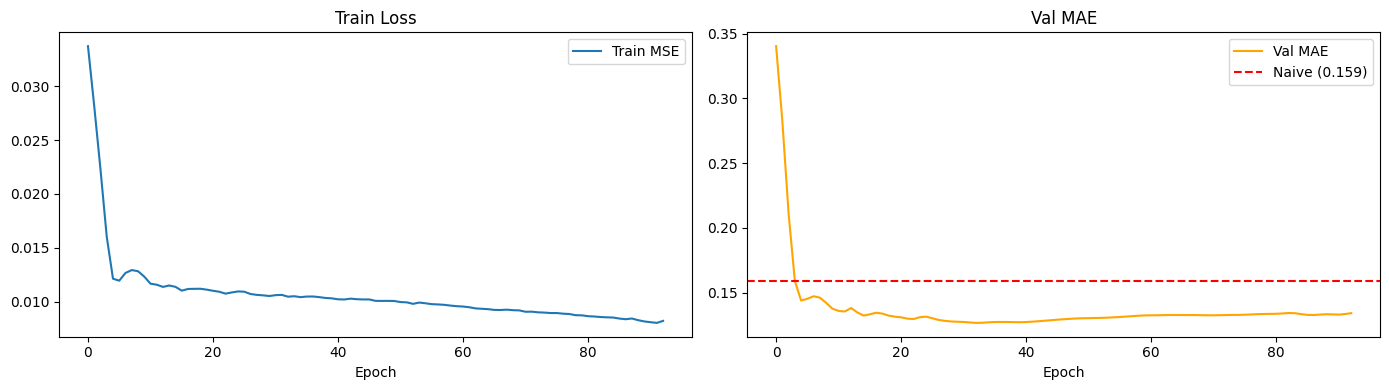


Класс                                 GNN MAE  Naive MAE
coating_deterioration_score             0.170      0.197
masonry_degradation_score               0.061      0.119
moisture_bio_damage_score               0.175      0.186
vandalism_score                         0.100      0.134


In [89]:
# кривые обучения и MAE по каждому классу повреждений
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(history["train_loss"], label="Train MSE")
axes[0].set_title("Train Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(history["val_mae"], label="Val MAE", color="orange")
axes[1].axhline(naive_val_mae, color="red", linestyle="--", label=f"Naive ({naive_val_mae:.3f})")
axes[1].set_title("Val MAE")
axes[1].set_xlabel("Epoch")
axes[1].legend()
plt.tight_layout()
plt.show()

model.eval()
with torch.no_grad():
    pred_all = model(data.x, data.edge_index).cpu().numpy()

y_val_np = data.y[data.val_mask].cpu().numpy()
pred_val_np = pred_all[data.val_mask.cpu().numpy()]
train_means_np = train_means.cpu().numpy()

print(f"\n{'Класс':<35} {'GNN MAE':>9} {'Naive MAE':>10}")
for i, col in enumerate(score_cols):
    gnn_mae = np.abs(y_val_np[:, i] - pred_val_np[:, i]).mean()
    naive_mae = np.abs(y_val_np[:, i] - train_means_np[i]).mean()
    print(f"{col:<35} {gnn_mae:>9.3f} {naive_mae:>10.3f}")

### 10. Предсказания для всех 14k зданий

In [ ]:
# сохраняем предсказания для всех зданий с лучшими весами модели
model.load_state_dict(best_state)
model.eval()
with torch.no_grad():
    pred_np = model(data.x, data.edge_index).cpu().numpy()

df_out = df[["building_id", "district_name", "centroid_lat", "centroid_lon",
             "r_year_int", "r_floors", "area_m2", "is_labeled"]].copy()

for i, col in enumerate(score_cols):
    pred_col = col.replace("_score", "_pred")
    df_out[pred_col] = pred_np[:, i].round(4)

for col in score_cols:
    df_out[col] = df[col]

out_path = root / "data/processed/gnn_predictions_similarity.csv"
df_out.to_csv(out_path, index=False)

### 11. Визуализация: предсказанные vs истинные

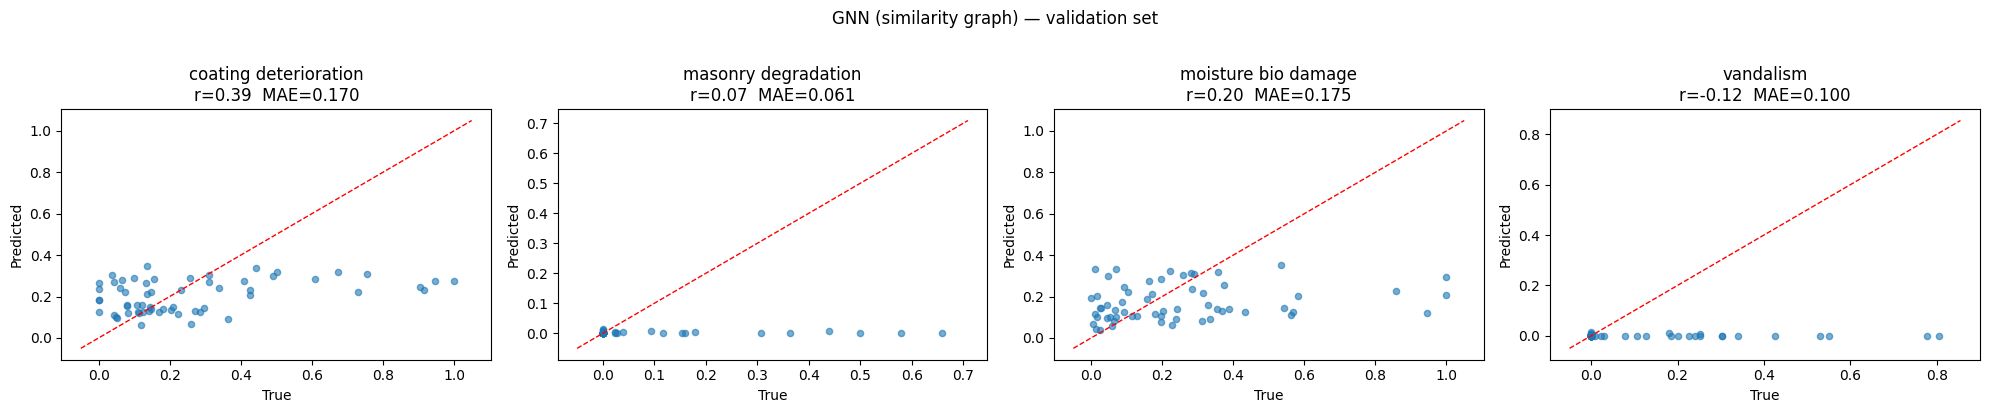

In [92]:
# scatter: предсказанные vs истинные скоры на val выборке
fig, axes = plt.subplots(1, len(score_cols), figsize=(5 * len(score_cols), 4))

for i, (col, ax) in enumerate(zip(score_cols, axes)):
    true_v = y_val_np[:, i]
    pred_v = pred_val_np[:, i]
    mask = ~np.isnan(true_v)
    t, p = true_v[mask], pred_v[mask]

    r, _ = pearsonr(t, p) if len(t) > 2 else (0, 1)
    mae = np.abs(t - p).mean()

    ax.scatter(t, p, alpha=0.6, s=20)
    lims = [min(t.min(), p.min()) - 0.05, max(t.max(), p.max()) + 0.05]
    ax.plot(lims, lims, "r--", lw=1)
    ax.set_xlabel("True")
    ax.set_ylabel("Predicted")
    short = col.replace("_score", "").replace("_", " ")
    ax.set_title(f"{short}\nr={r:.2f}  MAE={mae:.3f}")

plt.suptitle("GNN (similarity graph) — validation set", y=1.02)
plt.tight_layout()
plt.show()

# Эксперименты с GNN моделями (код полностью написан при помощи LLM)

### Этап 1. Поиск оптимальных гиперпараметров через Optuna

In [6]:
unlabeled_idx = np.where(df["is_labeled"].values == 0)[0]

_graph_cache = {}  # кэш графов, чтобы не перестраивать при каждом запуске

def build_graph(graph_type, k):
    key = (graph_type, k)
    if key not in _graph_cache:
        if graph_type == 'spatial':
            coords = np.radians(df[['centroid_lat', 'centroid_lon']].values)
            dist, idx = BallTree(coords, metric='haversine').query(coords, k=k+1)
        else:
            dist, idx = BallTree(X_sim, metric='euclidean').query(X_sim, k=k+1)
        n = len(idx)
        src = np.repeat(np.arange(n), k)
        dst = idx[:, 1:].flatten()
        sigma = np.median(dist[:, 1:])
        w = np.exp(-dist[:, 1:].flatten() / sigma)
        _graph_cache[key] = (
            torch.tensor([src, dst], dtype=torch.long),
            torch.tensor(w, dtype=torch.float)
        )
    return _graph_cache[key]


def build_subgraph(ei, ea, labeled_fraction, seed=0):
    rng = np.random.RandomState(seed)
    n_keep = max(1, int(len(unlabeled_idx) * labeled_fraction))
    keep = np.sort(np.concatenate([
        train_idx, val_idx,
        rng.choice(unlabeled_idx, n_keep, replace=False)
    ]))
    n = len(keep)
    old2new = np.full(x.shape[0], -1, dtype=np.int64)
    old2new[keep] = np.arange(n)

    src, dst = ei.numpy()
    m = (old2new[src] >= 0) & (old2new[dst] >= 0)
    ei_s = torch.tensor([old2new[src[m]], old2new[dst[m]]], dtype=torch.long)

    tr_mask = torch.zeros(n, dtype=torch.bool)
    vl_mask = torch.zeros(n, dtype=torch.bool)
    tr_mask[old2new[train_idx]] = True
    vl_mask[old2new[val_idx]] = True

    return ei_s, ea[m], x[keep], y[keep], tr_mask, vl_mask


def apply_lp(x_s, ei_s, tr_mask, y_s, steps=10):
    n = x_s.shape[0]
    y_prop = torch.zeros(n, y_s.shape[1])
    y_prop[tr_mask] = y_s[tr_mask]
    src, dst = ei_s
    for _ in range(steps):
        agg = torch.zeros_like(y_prop)
        cnt = torch.zeros(n, 1)
        agg.scatter_add_(0, dst.unsqueeze(1).expand(-1, y_s.shape[1]), y_prop[src])
        cnt.scatter_add_(0, dst.unsqueeze(1), torch.ones(len(src), 1))
        upd = (cnt.squeeze() > 0)
        upd[tr_mask] = False
        y_prop[upd] = (agg / cnt.clamp(min=1))[upd]
    return torch.cat([x_s, y_prop], dim=1)


def smooth_loss(pred, ei, ea):
    s, d = ei
    return (ea.unsqueeze(1) * (pred[s] - pred[d]).pow(2)).mean()


class FlexModel(nn.Module):
    def __init__(self, in_ch, hidden, n_layers, dropout, arch, drop_edge_p=0.0):
        super().__init__()
        self.arch, self.dropout, self.drop_edge_p = arch, dropout, drop_edge_p
        dims = [in_ch] + [hidden] * (n_layers - 1) + [hidden // 2]
        if arch == 'sage':
            self.convs = nn.ModuleList(SAGEConv(dims[i], dims[i+1]) for i in range(n_layers))
        elif arch == 'gat':
            self.convs = nn.ModuleList(
                GATConv(dims[i], dims[i+1], heads=4, concat=False, dropout=dropout)
                for i in range(n_layers)
            )
        else:  # mlp
            self.convs = nn.ModuleList(nn.Linear(dims[i], dims[i+1]) for i in range(n_layers))
        self.head = nn.Linear(hidden // 2, 4)

    def forward(self, x, ei):
        if self.training and self.drop_edge_p > 0 and self.arch != 'mlp':
            ei = ei[:, torch.rand(ei.shape[1], device=x.device) > self.drop_edge_p]
        for layer in self.convs[:-1]:
            x = F.relu(layer(x, ei) if self.arch != 'mlp' else layer(x))
            x = F.dropout(x, p=self.dropout, training=self.training)
        x = F.relu(self.convs[-1](x, ei) if self.arch != 'mlp' else self.convs[-1](x))
        return torch.sigmoid(self.head(x))


def run_experiment(cfg):
    run = wandb.init(project='facade-damage-GNN-experiments', config=cfg, reinit=True)

    ei, ea = build_graph(cfg['graph_type'], cfg['k'])
    ei_s, ea_s, x_s, y_s, tr_mask, vl_mask = build_subgraph(ei, ea, cfg['labeled_fraction'])
    wandb.log({'labeled_pct': 402 / x_s.shape[0] * 100})

    if cfg['use_lp']:
        x_s = apply_lp(x_s, ei_s, tr_mask, y_s)

    d = Data(x=x_s, edge_index=ei_s, edge_attr=ea_s,
             y=y_s, train_mask=tr_mask, val_mask=vl_mask).to(device)

    model = FlexModel(d.x.shape[1], cfg['hidden'], cfg['n_layers'],
                      cfg['dropout'], cfg['arch'], cfg.get('drop_edge_p', 0.0)).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=cfg['lr'], weight_decay=cfg['wd'])
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, patience=20, factor=0.5, min_lr=1e-5)

    naive_mae = (d.y[d.val_mask] - d.y[d.train_mask].mean(0)).abs().mean().item()
    best_mae, no_imp, best_state = float('inf'), 0, None

    for epoch in range(1, cfg['max_epochs'] + 1):
        model.train(); opt.zero_grad()
        pred = model(d.x, d.edge_index)
        loss = F.huber_loss(pred[d.train_mask], d.y[d.train_mask], delta=cfg['huber_delta'])
        if cfg['lambda_smooth'] > 0 and cfg['arch'] != 'mlp':
            loss = loss + cfg['lambda_smooth'] * smooth_loss(pred, d.edge_index, d.edge_attr)
        loss.backward(); opt.step()

        model.eval()
        with torch.no_grad():
            val_mae = (model(d.x, d.edge_index)[d.val_mask] - d.y[d.val_mask]).abs().mean().item()
        sched.step(val_mae)
        wandb.log({'epoch': epoch, 'loss': loss.item(), 'val_mae': val_mae})

        if val_mae < best_mae:
            best_mae, no_imp = val_mae, 0
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        else:
            no_imp += 1
            if no_imp >= cfg['patience']:
                break

    model.load_state_dict(best_state); model.eval()
    with torch.no_grad():
        preds = model(d.x, d.edge_index).cpu()

    vt, vp = d.y[d.val_mask].cpu(), preds[d.val_mask.cpu()]
    summary = {'best_val_mae': best_mae, 'naive_mae': naive_mae,
               'improvement_pct': (naive_mae - best_mae) / naive_mae * 100}
    for i, col in enumerate(score_cols):
        summary[f'mae_{col[:12]}'] = (vp[:, i] - vt[:, i]).abs().mean().item()
    wandb.log(summary)
    run.finish()
    return best_mae



wandb.login()  # логинимся

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/neuralist/.netrc.
wandb: Currently logged in as: rimedheart (rimedheart-personal-use) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [19]:
def train_full(cfg):
    """Переобучает модель из конфига без wandb. Возвращает историю и предсказания на val."""
    # приводим int-параметры (из wandb могут прийти как float)
    cfg = dict(cfg)
    for key in ('k', 'hidden', 'n_layers', 'max_epochs', 'patience'):
        if key in cfg and cfg[key] is not None:
            cfg[key] = int(cfg[key])
    cfg.setdefault('max_epochs', 800)
    cfg.setdefault('patience', 60)
    cfg.setdefault('huber_delta', 0.2)
    cfg.setdefault('drop_edge_p', 0.0)
    cfg.setdefault('use_lp', False)
    cfg.setdefault('lambda_smooth', 0.0)


    n_keep = max(1, int(len(unlabeled_idx) * cfg['labeled_fraction']))
    rng_k  = np.random.RandomState(0)
    keep   = np.sort(np.concatenate([
        train_idx, val_idx,
        rng_k.choice(unlabeled_idx, n_keep, replace=False)
    ]))

    ei, ea = build_graph(cfg['graph_type'], cfg['k'])
    ei_s, ea_s, x_s, y_s, tr_mask, vl_mask = build_subgraph(
        ei, ea, cfg['labeled_fraction']
    )
    if cfg['use_lp']:
        x_s = apply_lp(x_s, ei_s, tr_mask, y_s)

    d = Data(x=x_s, edge_index=ei_s, edge_attr=ea_s,
             y=y_s, train_mask=tr_mask, val_mask=vl_mask).to(device)

    model = FlexModel(d.x.shape[1], cfg['hidden'], cfg['n_layers'],
                      cfg['dropout'], cfg['arch'], cfg['drop_edge_p']).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=cfg['lr'], weight_decay=cfg['wd'])
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(
        opt, patience=20, factor=0.5, min_lr=1e-5
    )

    naive_mae = (d.y[d.val_mask] - d.y[d.train_mask].mean(0)).abs().mean().item()
    best_mae, no_imp, best_state = float('inf'), 0, None
    history = []

    for epoch in range(1, cfg['max_epochs'] + 1):
        model.train(); opt.zero_grad()
        pred = model(d.x, d.edge_index)
        loss = F.huber_loss(pred[d.train_mask], d.y[d.train_mask],
                            delta=cfg['huber_delta'])
        if cfg['lambda_smooth'] > 0 and cfg['arch'] != 'mlp':
            loss = loss + cfg['lambda_smooth'] * smooth_loss(pred, d.edge_index, d.edge_attr)
        loss.backward(); opt.step()

        model.eval()
        with torch.no_grad():
            val_pred_all = model(d.x, d.edge_index)
            val_mae = (val_pred_all[d.val_mask] - d.y[d.val_mask]).abs().mean().item()
        sched.step(val_mae)
        history.append({'epoch': epoch, 'loss': loss.item(), 'val_mae': val_mae})

        if val_mae < best_mae:
            best_mae, no_imp = val_mae, 0
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        else:
            no_imp += 1
            if no_imp >= cfg['patience']:
                break

    model.load_state_dict(best_state); model.eval()
    with torch.no_grad():
        preds = model(d.x, d.edge_index).cpu()

    val_true = d.y[d.val_mask].cpu().numpy()
    val_pred = preds[d.val_mask.cpu()].numpy()
    per_class = {col: float(np.abs(val_pred[:, i] - val_true[:, i]).mean())
                 for i, col in enumerate(score_cols)}

    return {
        'cfg': cfg,
        'history': pd.DataFrame(history),
        'val_true': val_true,
        'val_pred': val_pred,
        'naive_mae': naive_mae,
        'best_mae': best_mae,
        'per_class': per_class,
        'all_pred': preds.numpy(),
        'model_state': best_state,   
        'keep': keep,                
    }


In [ ]:
optuna.logging.set_verbosity(optuna.logging.WARNING)

wandb_project = 'facade-damage-GNN-exp-final'

# два набора признаков: без архитектурных стилей и с ними
cols_15 = [
    'area_m2', 'perimeter_m', 'year_built', 'floors', 'last_modified_year',
    'distance_to_water_m', 'distance_to_major_road_m',
    'distance_to_metro_m', 'distance_to_tram_rail_m',
    'amenity_count_300m', 'distance_to_park_m', 'distance_to_pedestrian_m',
    'dist_Василеостровский район', 'dist_Петроградский район', 'dist_Центральный район',
]
cols_23 = cols_15 + [c for c in df.columns if c.startswith('style_')]
print(f"cols_15: {len(cols_15)}, cols_23: {len(cols_23)}")
print(f"Добавленные style_ признаки: {[c for c in cols_23 if c not in cols_15]}")

def setup_session(cols):
    """Обновляет глобальные X_sim и x под текущую сессию."""
    global X_sim, x
    X_sim = StandardScaler().fit_transform(df[cols].values)
    x = torch.tensor(StandardScaler().fit_transform(df[cols].values), dtype=torch.float)
    _graph_cache.clear()
    print(f"  признаков: {len(cols)}, узлов: {x.shape[0]}")

results_v2 = []  # храним все результаты между сессиями

def run_experiment_v2(cfg):
    seed = cfg.get('seed', 0)
    torch.manual_seed(seed); np.random.seed(seed)

    run = wandb.init(project=wandb_project, config=cfg, reinit=True)

    ei, ea = build_graph(cfg['graph_type'], cfg['k'])
    ei_s, ea_s, x_s, y_s, tr_mask, vl_mask = build_subgraph(ei, ea, cfg['labeled_fraction'])
    if cfg['use_lp']:
        x_s = apply_lp(x_s, ei_s, tr_mask, y_s)

    d = Data(x=x_s, edge_index=ei_s, edge_attr=ea_s,
             y=y_s, train_mask=tr_mask, val_mask=vl_mask).to(device)
    model = FlexModel(d.x.shape[1], cfg['hidden'], cfg['n_layers'],
                      cfg['dropout'], cfg['arch'], cfg['drop_edge_p']).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=cfg['lr'], weight_decay=cfg['wd'])
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, patience=20, factor=0.5, min_lr=1e-5)

    naive_mae = (d.y[d.val_mask] - d.y[d.train_mask].mean(0)).abs().mean().item()
    best_mae, no_imp, best_state = float('inf'), 0, None

    for epoch in range(1, cfg['max_epochs'] + 1):
        model.train(); opt.zero_grad()
        pred = model(d.x, d.edge_index)
        loss = F.huber_loss(pred[d.train_mask], d.y[d.train_mask], delta=cfg['huber_delta'])
        if cfg['lambda_smooth'] > 0 and cfg['arch'] != 'mlp':
            loss = loss + cfg['lambda_smooth'] * smooth_loss(pred, d.edge_index, d.edge_attr)
        loss.backward(); opt.step()

        model.eval()
        with torch.no_grad():
            val_mae = (model(d.x, d.edge_index)[d.val_mask] - d.y[d.val_mask]).abs().mean().item()
        sched.step(val_mae)
        wandb.log({'epoch': epoch, 'loss': loss.item(), 'val_mae': val_mae})

        if val_mae < best_mae:
            best_mae, no_imp = val_mae, 0
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        else:
            no_imp += 1
            if no_imp >= cfg['patience']:
                break

    wandb.log({'best_val_mae': best_mae, 'naive_mae': naive_mae})
    run.finish()

    results_v2.append({**cfg, 'best_val_mae': best_mae, 'naive_mae': naive_mae})
    pd.DataFrame(results_v2).to_csv('../data/processed/gnn_results_v2.csv', index=False)
    return best_mae

def make_objective(session, feature_set, vary_lf):
    def objective(trial):
        cfg = {
            'session': session,
            'feature_set': feature_set,
            'graph_type': trial.suggest_categorical('graph_type', ['spatial', 'similarity']),
            'arch': trial.suggest_categorical('arch', ['sage', 'gat', 'mlp']),
            'k': trial.suggest_int('k', 4, 16, step=2),
            'hidden': trial.suggest_categorical('hidden', [64, 128, 256]),
            'n_layers': trial.suggest_int('n_layers', 2, 4),
            'dropout': trial.suggest_float('dropout', 0.2, 0.5),
            'lambda_smooth': trial.suggest_float('lambda_smooth', 0.0, 0.05, step=0.01),
            'drop_edge_p': trial.suggest_float('drop_edge_p', 0.0, 0.4, step=0.1),
            'use_lp': trial.suggest_categorical('use_lp', [True, False]),
            'lr': trial.suggest_float('lr', 1e-4, 1e-2, log=True),
            'wd': trial.suggest_float('wd', 1e-5, 1e-3, log=True),
            'huber_delta': trial.suggest_float('huber_delta', 0.1, 0.4, step=0.1),
            'labeled_fraction': (
                trial.suggest_categorical('labeled_fraction', [0.25, 0.5, 0.75, 1.0])
                if vary_lf else 1.0
            ),
            'max_epochs': 400, 'patience': 40,
        }
        if cfg['arch'] == 'mlp':
            cfg.update({'lambda_smooth': 0.0, 'use_lp': False, 'drop_edge_p': 0.0})
        return run_experiment_v2(cfg)
    return objective

cols_15: 15, cols_23: 23
Добавленные style_ признаки: ['style_baroque', 'style_classicism', 'style_constructivism', 'style_eclecticism', 'style_modern', 'style_neoclassicism', 'style_unknown', 'style_vernacular']


сессия 1: 15 признаков, labeled_fraction=1.0

In [ ]:
print("Сессия 1: 15 признаков, labeled_fraction=1.0")
setup_session(cols_15)
study1 = optuna.create_study(direction='minimize',
                              sampler=optuna.samplers.TPESampler(seed=42))
study1.optimize(make_objective('15f_fixed_lf', '15feat', vary_lf=False),
                n_trials=60, show_progress_bar=True)
print(f"Лучший MAE: {study1.best_value:.4f}")


сессия 2: 15 признаков, labeled_fraction варьируется

In [ ]:
print("Сессия 2: 15 признаков, labeled_fraction варьируется")
setup_session(cols_15)
study2 = optuna.create_study(direction='minimize',
                              sampler=optuna.samplers.TPESampler(seed=42))
study2.optimize(make_objective('15f_vary_lf', '15feat', vary_lf=True),
                n_trials=60, show_progress_bar=True)
print(f"Лучший MAE: {study2.best_value:.4f}")


сессия 3: 23 признака, labeled_fraction варьируется

In [9]:
results_v2 = pd.read_csv('../data/processed/gnn_results_v2.csv').to_dict('records')

In [ ]:
print("Сессия 3: 23 признака (с r_style), labeled_fraction=1.0")
setup_session(cols_23)
study3 = optuna.create_study(direction='minimize',
                              sampler=optuna.samplers.TPESampler(seed=42))
study3.optimize(make_objective('23f_fixed_lf', '23feat', vary_lf=False),
                n_trials=60, show_progress_bar=True)
print(f"Лучший MAE: {study3.best_value:.4f}")


### Вывод результатов

In [12]:
df_res = pd.read_csv('../data/processed/gnn_results_v2.csv')
df_gnn = df_res[df_res['arch'].isin(['sage', 'gat'])]
naive_mae = df_res['naive_mae'].iloc[0]
df_mlp = df_res[df_res['arch'] == 'mlp']
print("\nЛучший MAE для MLP (граф не используется):")
print(df_mlp.groupby('session')['best_val_mae'].min().round(4))


print(f"Ранов по сессиям:\n{df_res['session'].value_counts().to_string()}")
print(f"\nНаивный baseline: {naive_mae:.4f}")
print("\nЛучший MAE по (session, graph_type, arch):")
pivot = (df_gnn.groupby(['session', 'graph_type', 'arch'])['best_val_mae']
               .min().unstack(['graph_type', 'arch']))
print(pivot.round(4))


Лучший MAE для MLP (граф не используется):
session
15f_fixed_lf    0.1221
15f_vary_lf     0.1270
23f_fixed_lf    0.1256
Name: best_val_mae, dtype: float64
Ранов по сессиям:
session
15f_fixed_lf    60
23f_fixed_lf    60
15f_vary_lf     48

Наивный baseline: 0.1591

Лучший MAE по (session, graph_type, arch):
graph_type   similarity         spatial        
arch                gat    sage     gat    sage
session                                        
15f_fixed_lf     0.1283  0.1225  0.1251  0.1182
15f_vary_lf      0.1159  0.1204  0.1348  0.1245
23f_fixed_lf     0.1317  0.1294  0.1308  0.1230


In [17]:
sessions = ['15f_fixed_lf', '15f_vary_lf', '23f_fixed_lf']
hyp_cols = ['arch', 'graph_type', 'k', 'hidden', 'n_layers', 'dropout',
            'lr', 'wd', 'lambda_smooth', 'drop_edge_p', 'use_lp',
            'huber_delta', 'labeled_fraction']

rows = []
for sess in sessions:
    df_s = df_res[df_res['session'] == sess]
    df_s_g = df_s[df_s['arch'].isin(['sage', 'gat'])]
    df_s_m = df_s[df_s['arch'] == 'mlp']

    best_gnn = df_s_g.nsmallest(1, 'best_val_mae').iloc[0]
    best_mlp = df_s_m.nsmallest(1, 'best_val_mae').iloc[0]

    rows.append({
        'session': sess,
        'naive': round(naive_mae, 4),
        'mlp': round(best_mlp['best_val_mae'], 4),
        'gnn': round(best_gnn['best_val_mae'], 4),
        'gnn_imp': f"{(naive_mae - best_gnn['best_val_mae']) / naive_mae * 100:+.1f}%",
    })

print("Сравнение моделей:")
print(pd.DataFrame(rows).to_string(index=False))

print("\nГиперпараметры лучших GNN:")
best_gnns = [df_res[(df_res['session']==s) & df_res['arch'].isin(['sage','gat'])]
             .nsmallest(1, 'best_val_mae').iloc[0] for s in sessions]
print(pd.DataFrame(best_gnns)[['session'] + hyp_cols + ['best_val_mae']].to_string(index=False))

print("\nГиперпараметры лучших MLP:")
best_mlps = [df_res[(df_res['session']==s) & (df_res['arch']=='mlp')]
             .nsmallest(1, 'best_val_mae').iloc[0] for s in sessions]
print(pd.DataFrame(best_mlps)[['session'] + hyp_cols + ['best_val_mae']].to_string(index=False))

Сравнение моделей:
     session  naive    mlp    gnn gnn_imp
15f_fixed_lf 0.1591 0.1221 0.1182  +25.7%
 15f_vary_lf 0.1591 0.1270 0.1159  +27.1%
23f_fixed_lf 0.1591 0.1256 0.1230  +22.7%

Гиперпараметры лучших GNN:
     session arch graph_type  k  hidden  n_layers  dropout       lr       wd  lambda_smooth  drop_edge_p  use_lp  huber_delta  labeled_fraction  best_val_mae
15f_fixed_lf sage    spatial 14      64         3 0.417403 0.007350 0.000010           0.00          0.3    True          0.1              1.00      0.118231
 15f_vary_lf  gat similarity  4     256         3 0.389929 0.000405 0.000016           0.05          0.4    True          0.1              0.75      0.115926
23f_fixed_lf sage    spatial 12     128         4 0.259870 0.005009 0.000232           0.01          0.2   False          0.4              1.00      0.122991

Гиперпараметры лучших MLP:
     session arch graph_type  k  hidden  n_layers  dropout       lr       wd  lambda_smooth  drop_edge_p  use_lp  huber_delta

### Этап 2. Проверка гипотез

### Фиксированные и перебираемые гиперпараметры

In [9]:
base_cfg = {
    'n_layers':         3,
    'hidden':           128,
    'dropout':          0.4,
    'lr':               0.002,
    'wd':               1e-5,
    'lambda_smooth':    0.01,
    'drop_edge_p':      0.35,
    'use_lp':           True,
    'huber_delta':      0.1,
    'max_epochs':       300,
    'patience':         30,
    'feature_set':      '15feat',
    'session':          'ablation_v2',
    'labeled_fraction': 1.0,
}

grid = {
    'arch':       ['sage', 'gat'],
    'graph_type': ['spatial', 'similarity'],
    'k':          [2, 4, 6, 8, 10, 12, 14, 16],
}

seeds = [0, 1, 2]
total = 2 * 2 * 8 * len(seeds)
print(f"Всего запусков: {total}")  # 96

Всего запусков: 96


### Сетка экспериментов

In [ ]:
setup_session(cols_15)

combos = list(itertools.product(grid['arch'], grid['graph_type'], grid['k'], seeds))

for i, (arch, graph_type, k, seed) in enumerate(combos):
    cfg = {**base_cfg, 'arch': arch, 'graph_type': graph_type, 'k': k, 'seed': seed}
    mae = run_experiment_v2(cfg)
    if (i + 1) % 10 == 0:
        print(f"[{i+1}/{total}] arch={arch}, graph={graph_type}, k={k}, seed={seed}: MAE={mae:.4f}")

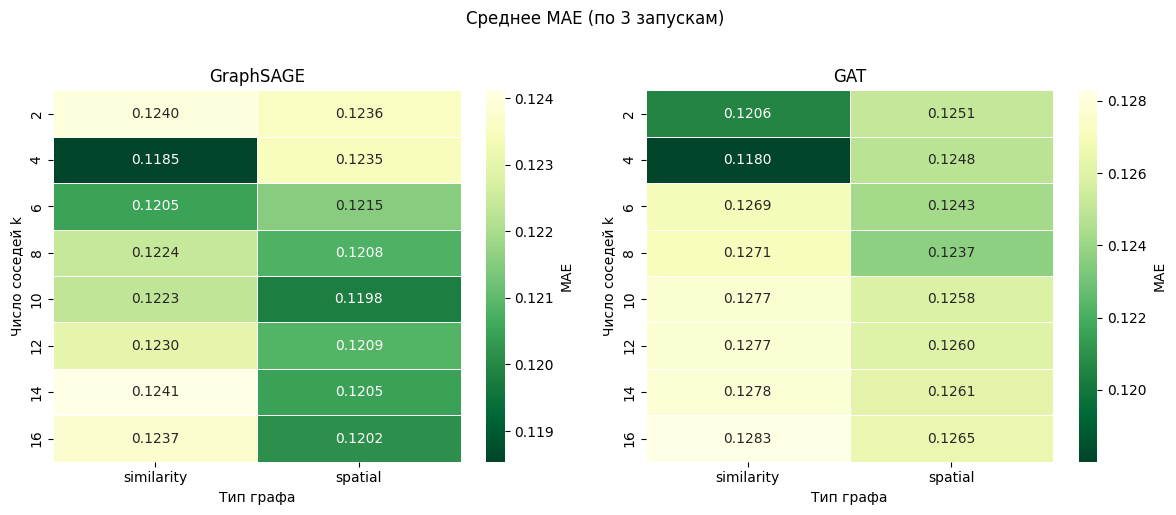

In [ ]:
df_v2 = pd.read_csv('../data/interim/gnn_results_v2.csv')
df_abl2 = df_v2[df_v2['session'] == 'ablation_v2']

# среднее MAE по 3 запускам с разными сидами
df_mean = (df_abl2
    .groupby(['arch', 'graph_type', 'k'])['best_val_mae']
    .mean()
    .reset_index())

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, arch in zip(axes, ['sage', 'gat']):
    pivot = (df_mean[df_mean['arch'] == arch]
        .pivot(index='k', columns='graph_type', values='best_val_mae'))
    sns.heatmap(pivot, ax=ax, annot=True, fmt='.4f', cmap='YlGn_r',
                linewidths=0.5, cbar_kws={'label': 'MAE'})
    ax.set_title('GraphSAGE' if arch == 'sage' else 'GAT')
    ax.set_xlabel('Тип графа')
    ax.set_ylabel('Число соседей k')

plt.suptitle('Среднее MAE (по 3 запускам)', y=1.02)
plt.tight_layout()
plt.show()

Задаем конфиг конкретной модели и обучаем ее

In [22]:
setup_session(cols_15)

cfg = {
    'arch': 'gat', 'graph_type': 'similarity', 'k': 4,
    'hidden': 128, 'n_layers': 3, 'dropout': 0.4,
    'lr': 0.002, 'wd': 1e-5, 'lambda_smooth': 0.02,
    'drop_edge_p': 0.35, 'use_lp': True, 'huber_delta': 0.1,
    'labeled_fraction': 1.0, 'max_epochs': 400, 'patience': 40,
}

cfg_mlp = {**cfg, 'arch': 'mlp', 'lambda_smooth': 0.0,
           'use_lp': False, 'drop_edge_p': 0.0}

r_gnn = train_full(cfg)
r_mlp = train_full(cfg_mlp)
naive_mae = r_gnn['naive_mae']
print(f"MAE: {r_gnn['best_mae']:.4f}  (naive: {r_gnn['naive_mae']:.4f})")
print(f"MLP MAE: {r_mlp['best_mae']:.4f}")

# сводная таблица
print("\nСравнение моделей:")
print(f"  {'Наивный':20s}: {naive_mae:.4f}")
print(f"  {'MLP':20s}: {r_mlp['best_mae']:.4f}  ({(naive_mae - r_mlp['best_mae'])/naive_mae*100:+.1f}%)")
print(f"  {'GNN':20s}: {r_gnn['best_mae']:.4f}  ({(naive_mae - r_gnn['best_mae'])/naive_mae*100:+.1f}%)")

  признаков: 15, узлов: 14354
MAE: 0.1168  (naive: 0.1591)
MLP MAE: 0.1260

Сравнение моделей:
  Наивный             : 0.1591
  MLP                 : 0.1260  (+20.8%)
  GNN                 : 0.1168  (+26.6%)


In [23]:
# Сохранение
torch.save(r_gnn['model_state'], '../models/gnn_gat_similarity_k4.pt')

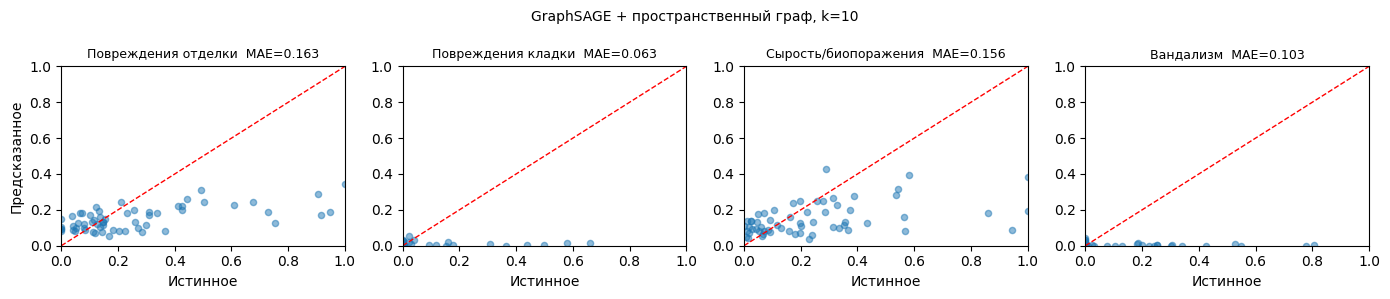

In [ ]:
score_labels = ['Повреждения отделки', 'Повреждения кладки', 'Сырость/биопоражения', 'Вандализм']

fig2, axes2 = plt.subplots(1, 4, figsize=(14, 3))
for i, (lbl, ax) in enumerate(zip(score_labels, axes2)):
    vt = r_gnn['val_true'][:, i]
    vp = r_gnn['val_pred'][:, i]
    mae_i = np.abs(vt - vp).mean()
    ax.scatter(vt, vp, alpha=0.5, s=20)
    ax.plot([0, 1], [0, 1], 'r--', lw=1)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.set_title(f'{lbl}  MAE={mae_i:.3f}', fontsize=9)
    ax.set_xlabel('Истинное')
    if i == 0: ax.set_ylabel('Предсказанное')

arch_title = 'GraphSAGE' if cfg['arch'] == 'sage' else 'GAT'
graph_title = 'граф схожести' if cfg['graph_type'] == 'similarity' else 'пространственный граф'
fig2.suptitle(f"{arch_title} + {graph_title}, k={cfg['k']}", fontsize=10)
plt.tight_layout()
plt.show()

## валидация

In [25]:
score_cols_base = ['coating_deterioration_score', 'masonry_degradation_score',
                   'moisture_bio_damage_score', 'vandalism_score']
score_labels = ['Повреждения отделки', 'Повреждения кладки', 'Сырость/биопоражения', 'Вандализм']

val = pd.read_csv('../data/interim/gnn-validation/83-buildings-indices.csv')
pred_gat = pd.read_csv('../data/output/gnn_predictions_all_gat.csv')
pred_sage = pd.read_csv('../data/output/gnn_predictions_all_sage.csv')

gat_pred_cols = pred_gat[['building_id'] + score_cols_base].rename(columns={c: c+'_gat' for c in score_cols_base})
sage_pred_cols = pred_sage[['building_id'] + score_cols_base].rename(columns={c: c+'_sage' for c in score_cols_base})

df_val = (val
    .rename(columns={c: c+'_true' for c in score_cols_base})
    .merge(gat_pred_cols, left_on='building_name', right_on='building_id')
    .merge(sage_pred_cols, left_on='building_name', right_on='building_id')
)
print(f"Зданий в валидации: {len(df_val)}")

naive_means = pred_gat[pred_gat['is_labeled'] == 1][score_cols_base].mean()

rows = []
for col, label in zip(score_cols_base, score_labels):
    true = df_val[f'{col}_true'].values
    rows.append({
        'Класс': label,
        'Naive MAE': np.abs(true - naive_means[col]).mean(),
        'GAT MAE': np.abs(true - df_val[f'{col}_gat'].values).mean(),
        'SAGE MAE': np.abs(true - df_val[f'{col}_sage'].values).mean(),
        'GAT Spearman': stats.spearmanr(true, df_val[f'{col}_gat'].values)[0],
        'SAGE Spearman': stats.spearmanr(true, df_val[f'{col}_sage'].values)[0],
    })

print(pd.DataFrame(rows).round(3).to_string(index=False))

Зданий в валидации: 83
               Класс  Naive MAE  GAT MAE  SAGE MAE  GAT Spearman  SAGE Spearman
 Повреждения отделки      0.175    0.189     0.185         0.123          0.206
  Повреждения кладки      0.076    0.071     0.065        -0.115         -0.170
Сырость/биопоражения      0.225    0.207     0.201         0.155          0.352
           Вандализм      0.048    0.043     0.035        -0.178         -0.011


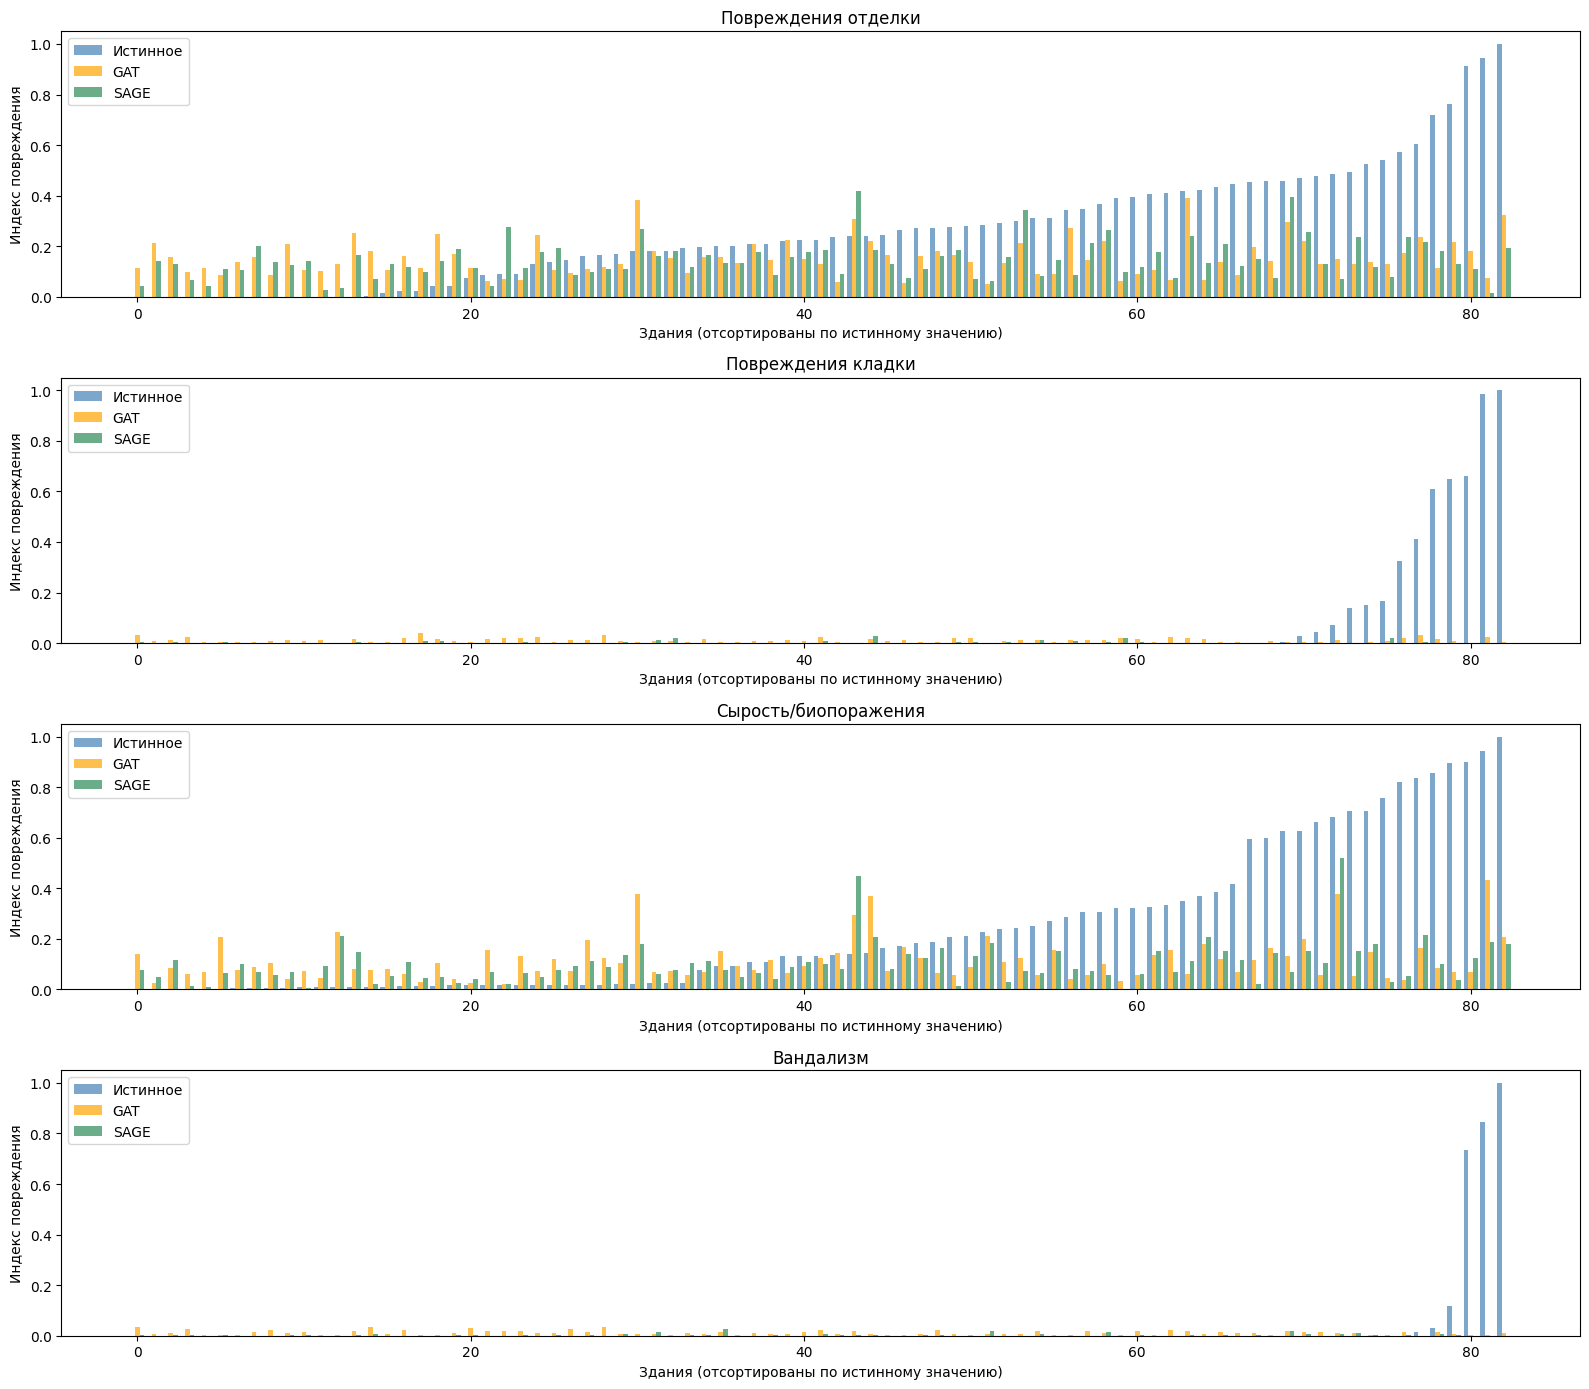

In [ ]:
fig, axes = plt.subplots(4, 1, figsize=(16, 14))
w = 0.28

for i, (col, label) in enumerate(zip(score_cols_base, score_labels)):
    ax = axes[i]
    df_sorted = df_val.sort_values(f'{col}_true').reset_index(drop=True)
    x = np.arange(len(df_sorted))

    ax.bar(x - w, df_sorted[f'{col}_true'],  width=w, alpha=0.7, label='Истинное',  color='steelblue')
    ax.bar(x,     df_sorted[f'{col}_gat'],   width=w, alpha=0.7, label='GAT',       color='orange')
    ax.bar(x + w, df_sorted[f'{col}_sage'],  width=w, alpha=0.7, label='SAGE',      color='seagreen')

    ax.set_title(label)
    ax.set_ylabel('Индекс повреждения')
    ax.set_xlabel('Здания (отсортированы по истинному значению)')
    ax.legend()

plt.tight_layout()
plt.show()

